In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math, time
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import joblib

import matplotlib.pyplot as plt
plt.rc('font', family='SimHei', size=14)  ##显示中文

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = './OutputData/G3.xlsx'
df = pd.read_excel(file_path)
# 将“时间”列转换为 datetime 类型，方便按时间属性筛选
# df["时间"] = pd.to_datetime(df["时间"])
# df = df[(df["时间"].dt.minute == 0) & (df["时间"].dt.second == 0)]
# df.to_excel("./OutputData/G3.xlsx",index=False)

In [3]:
df

,时间,监测值
0,2025-01-16 15:00:00,672.087
1,2025-01-16 16:00:00,672.076
2,2025-01-16 17:00:00,672.043
3,2025-01-23 15:00:00,672.305
4,2025-01-23 16:00:00,672.302
...,...,...
3102,2025-07-16 08:00:00,724.313
3103,2025-07-16 09:00:00,724.596
3104,2025-07-16 10:00:00,724.917
3105,2025-07-16 11:00:00,725.224


In [4]:
# target为要输入的数据,lookback为序列长度
def split_data(target, lookback):
    data_raw = target.to_numpy() 
    data = []
    
    # you can free play（seq_length）
    for index in range(len(data_raw) - lookback + 1 ): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data);

    # 设置测试集天数为最近30天的数据
    test_set_size = 0
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [5]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [6]:
# 模型超参数
input_dim = 1
hidden_dim = 50
num_layers = 3
output_dim = 1
lookback = 50
num_epochs = 500

# 该目录用于保存最优模型参数
os.makedirs('models', exist_ok=True)
# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('scalers', exist_ok=True)


# 提取标签
target = df[['监测值']].copy()

#归一化
scaler = MinMaxScaler(feature_range=(-1, 1))
target['监测值'] = scaler.fit_transform(target['监测值'].values.reshape(-1,1))

best_scaler_path = 'scalers/' + 'G3_scaler.pkl'
print('模型标准化格式保存路径：',best_scaler_path)

# 保存标准化参数
joblib.dump(scaler, best_scaler_path)

#划分训练集、验证集、测试集
x_train, y_train , _ , _ = split_data(target, lookback)

print('x_train shape:',x_train.shape)
print('y_trian shape:',y_train.shape)

模型标准化格式保存路径： scalers/G3_scaler.pkl
x_train shape: (3058, 49, 1)
y_trian shape: (3058, 1)


In [7]:
# 转换成张量,神经网络模型的数据要求为张量类型
x_train = torch.from_numpy(x_train).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)

# 模型实例化准备开始训练
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

import time

hist = np.zeros(num_epochs)
best_train_loss = float('inf')  # 用于保存验证集上的最佳损失
best_model_path = 'models/' + 'G3_model.pth'  # 最佳模型保存路径
print('最优模型参数保存路径：',best_model_path)

start_time = time.time()
lstm = []

for t in range(num_epochs):
    # 训练模式
    model.train()
    
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    hist[t] = loss.item()
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # 验证模式
    model.eval()
    with torch.no_grad():  # 禁用梯度计算
        
        # 反归一化
        y_train_pred_1 = scaler.inverse_transform(y_train_pred.detach().numpy())
        y_train_1 = scaler.inverse_transform(y_train_lstm.detach().numpy())
        # 计算真实MSE
        train_loss = math.sqrt(mean_squared_error(y_train_pred_1[:, 0], y_train_1[:, 0]))
        print("Epoch ", t, "Train RMSE: ", train_loss)

        # 如果验证损失更好，则保存模型
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {t} with Train RMSE: {best_train_loss}")
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))


最优模型参数保存路径： models/G3_model.pth
Epoch  0 Train RMSE:  21.410080348456045
Best model saved at epoch 0 with Train RMSE: 21.410080348456045
Epoch  1 Train RMSE:  14.860682673631356
Best model saved at epoch 1 with Train RMSE: 14.860682673631356
Epoch  2 Train RMSE:  5.7787905848697525
Best model saved at epoch 2 with Train RMSE: 5.7787905848697525
Epoch  3 Train RMSE:  5.335215931663458
Best model saved at epoch 3 with Train RMSE: 5.335215931663458
Epoch  4 Train RMSE:  5.999701492513405
Epoch  5 Train RMSE:  5.513950688132975
Epoch  6 Train RMSE:  5.141888587815932
Best model saved at epoch 6 with Train RMSE: 5.141888587815932
Epoch  7 Train RMSE:  5.689628454323023
Epoch  8 Train RMSE:  5.057842985431952
Best model saved at epoch 8 with Train RMSE: 5.057842985431952
Epoch  9 Train RMSE:  5.117527608270534
Epoch  10 Train RMSE:  5.352262621002875
Epoch  11 Train RMSE:  5.085517830827655
Epoch  12 Train RMSE:  4.845410265485178
Best model saved at epoch 12 with Train RMSE: 4.8454102654851

In [8]:
# 加载最优模型参数
model.load_state_dict(torch.load(best_model_path,weights_only=True))  
model.eval()  # 将模型设置为评估模式

# 加载归一化格式
scaler = joblib.load(best_scaler_path)

 # 得到最好预测
with torch.no_grad():  # 禁用梯度计算
    y_train_pred = model(x_train)
    
# 训练预测值反归一化
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
# 训练原始值反归一化
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())


# 计算MSE
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.3f RMSE' % (trainScore))

Train Score: 0.526 RMSE


# 模型可视化

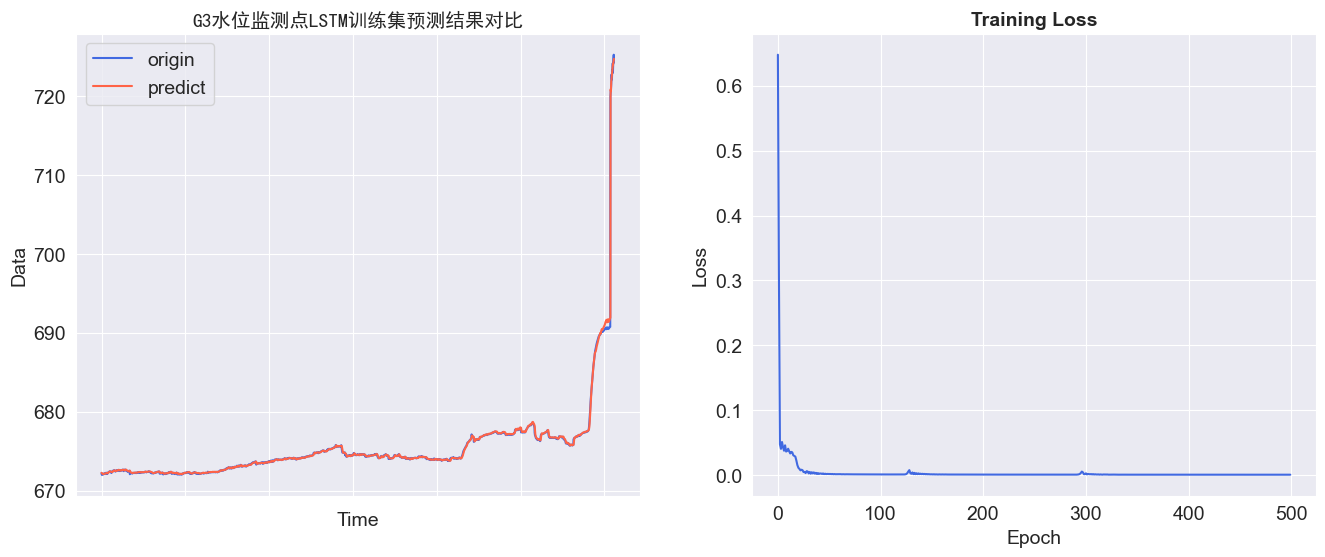

In [10]:
y_train = pd.DataFrame(y_train)
y_train_pred = pd.DataFrame(y_train_pred)

# 模型结果可视化
sns.set_style("darkgrid")
fig = plt.figure()
fig.subplots_adjust(hspace=0.2,wspace=0.2)
plt.subplot(1,2,1)
ax = sns.lineplot(x=y_train.index,y=y_train[0],label="origin",color='royalblue')
ax = sns.lineplot(x=y_train_pred.index,y=y_train_pred[0],label="predict",color='tomato')
ax.set_title(f'G3水位监测点LSTM训练集预测结果对比',size=14,fontweight='bold',fontfamily=["SimHei"])
ax.set_xlabel("Time",size=14)
ax.set_ylabel("Data",size=14)
ax.set_xticklabels('',size=10)

plt.subplot(1,2,2)
ax = sns.lineplot(data=hist,color='royalblue')
ax.set_xlabel("Epoch",size=14)
ax.set_ylabel("Loss",size=14)
ax.set_title("Training Loss",size=14,fontweight='bold')
fig.set_figheight(6)
fig.set_figwidth(16)
plt.savefig('./images/G3.png', dpi=300, bbox_inches='tight')

plt.show()